In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'
TEST_YEAR = '2024'
TEST_MONTH = '5'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
trained_model = pickle.load(open(f'../../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_2010-2023_WNV_Trained_Model.pkl', 'rb'))
scaler = pickle.load(open(f'../../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_2010-2023_WNV_Scaler.pkl', 'rb'))
imputer = pickle.load(open(f'../../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_2010-2023_WNV_Imputer.pkl', 'rb'))
feature_names = pickle.load(open(f'../../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_2010-2023_WNV_Feature_List.pkl', 'rb'))

In [4]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'

test_file = f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_{TEST_YEAR}.csv'
data_test = read_data(test_file)
data_test.reset_index(drop = True, inplace = True)
print(data_test.shape)

(42, 112)


In [5]:
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL521,2024,1,22.217953,40.552111,0.299434,0.065404,-0.246213,-0.065404,0.291434,0.059297,-0.240757,-0.059297,0.057744,0.055104,0.060754,0.055104,9.610420,9.807407,9.695794,16.031637,16.031637,3.935148,2.377587,0.547431,4.877013,4.877013,6.772784,6.092497,5.121613,10.454325,10.454325,0.018889,12.804815,1.203297,0.307600,4.230611,26.858546,637.070049,839.462963,27.079450,15.291667,17.250000,43.125000,753.916541,35.0,-5.0,40.0,16.833333,10.000000,24.500000,6.000000,632.0,130.0,11.0,84.957254,327.0,54.0,62.0,84.0,31,36,30,12,12,1,6,4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,9395.0,40105.0,14525.0,64025.0,8763.0,39435.0,18365.0,66563.0,1529.23,1706.0,2112.0,0
1,EL522,2024,1,23.139033,40.693632,0.285067,0.041823,-0.237645,-0.041823,0.270317,0.030713,-0.227904,-0.030713,0.059028,0.065498,0.050015,0.065498,9.969719,11.263800,10.597199,15.937510,15.937510,3.958646,3.142944,0.915352,5.304677,5.304677,6.964182,7.203372,5.756275,10.621094,10.621094,-0.682187,12.919844,2.105668,0.004274,1.560940,59.248563,575.022830,754.937500,24.352823,16.291667,18.583333,42.234848,822.539950,39.0,-5.0,44.0,8.000000,8.500000,26.833333,6.666667,570.0,133.0,0.0,82.518732,227.0,61.0,66.0,98.0,31,36,30,12,12,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,77246.0,347509.0,95491.0,520246.0,73683.0,368528.0,127954.0,570165.0,14404.36,21757.0,19223.0,0
2,EL523,2024,1,22.762317,41.016275,0.234162,-0.107059,-0.231648,0.107059,0.227918,-0.103591,-0.225353,0.103591,0.042120,0.040287,0.040109,0.040287,10.505804,10.720011,11.521623,16.884025,16.884025,2.967362,2.339599,0.145427,4.727602,4.727602,6.736583,6.529805,5.833525,10.805813,10.805813,-1.618913,13.429130,0.651083,0.172098,1.396813,13.543434,507.585429,822.684783,26.538219,16.625000,20.250000,44.021739,857.884555,41.0,-5.0,46.0,18.666667,6.666667,27.666667,6.666667,502.0,125.0,4.0,86.675281,211.0,45.0,76.0,45.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0

In [6]:
data_test = encode_cyclical(data_test, 'month', 12)

In [7]:
len(data_test.NUTS3_ID.unique())

7

In [8]:
data_test = data_test.query(f'month == {TEST_MONTH}')
data_test.reset_index(drop=True, inplace=True)

In [9]:
data_test.head(10)

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases,month_sin,month_cos
0,EL521,2024,5,22.217953,40.552111,0.469605,0.112465,-0.410177,-0.112465,0.463576,0.114667,-0.403961,-0.114667,0.053791,0.052618,0.040323,0.052618,25.236637,7.495806,11.969080,15.628925,25.236637,10.723689,1.773059,3.472199,5.653668,10.723689,17.980163,4.634432,7.720640,10.641296,17.980163,7.056667,29.077778,3.670017,3.822502,105.505747,106.430496,275.061515,1175.222222,39.174074,15.291667,17.250000,43.125000,753.916541,35.0,-5.0,40.0,16.833333,10.000000,24.500000,6.000000,632.0,130.0,11.0,84.957254,327.0,54.0,62.0,84.0,31,36,30,12,12,1,6,4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,9395.0,40105.0,14525.0,64025.0,8763.0,39435.0,18365.0,66563.0,1529.23,1706.0,2112.0,0,0.5,-0.866025
1,EL522,2024,5,23.139033,40.693632,0.457133,0.148089,-0.396464,-0.148089,0.444606,0.144394,-0.386455,-0.144394,0.060817,0.059385,0.049723,0.059385,25.260156,8.653382,13.224235,15.961008,25.260156,10.953750,1.898629,3.790065,6.232308,10.953750,18.106953,5.276006,8.507150,11.096658,18.106953,3.412188,30.568281,5.148134,1.105302,141.898502,149.295880,387.807936,639.414062,21.313802,16.291667,18.583333,42.234848,822.539950,39.0,-5.0,44.0,8.000000,8.500000,26.833333,6.666667,570.0,133.0,0.0,82.518732,227.0,61.0,66.0,98.0,31,36,30,12,12,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,77246.0,347509.0,95491.0,520246.0,73683.0,368528.0,127954.0,570165.0,14404.36,21757.0,19223.0,0,0.5,-0.866025
2,EL523,2024,5,22.762317,41.016275,0.531305,0.155117,-0.464835,-0.155117,0.542404,0.175067,-0.470161,-0.175067,0.052459,0.058467,0.037488,0.058467,25.470522,8.469299,14.175660,16.577160,25.470522,10.624087,0.607805,2.928861,5.633261,10.624087,18.047304,4.538552,8.552260,11.105210,18.047304,4.831304,30.272609,4.119086,1.492255,118.337585,119.453494,289.523216,687.967391,22.932246,16.625000,20.250000,44.021739,857.884555,41.0,-5.0,46.0,18.666667,6.666667,27.666667,6.666667,502.0,125.0,4.0,86.675281,211.0,45.0,76.0,45.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489

In [10]:
features = data_test.loc[:, data_test.columns.isin(feature_names)].columns
print(features.to_list())

print(f"Total Features Used: {len(features)}")

['ndvi', 'ndmi', 'ndwi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_gt65', 'mio_eur', 'l_total', 'unl_total', 'month_sin', 'month_cos']
Total Features Used: 64


In [11]:
X_test = data_test.loc[:, data_test.columns.isin(feature_names)]
y_test = data_test['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.fit_transform(X_test_scaled)

y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

In [12]:
results = pd.concat([data_test.iloc[:, :5], pd.Series(y_test_prob, name='score')], axis=1)

In [13]:
results.sort_values(by='score', ascending=False).head(5)

,NUTS3_ID,year,month,x,y,score
1,EL522,2024,5,23.139033,40.693632,0.035358
2,EL523,2024,5,22.762317,41.016275,0.006745
3,EL524,2024,5,22.109782,40.888821,0.003850
5,EL526,2024,5,23.544035,41.084331,0.002697
0,EL521,2024,5,22.217953,40.552111,0.002387


In [14]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"

greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [15]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326


In [16]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL52,Κεντρική Μακεδονία,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [17]:
greece_nuts3_gdf.head()

,NUTS3_ID,NUTS3_NAME,geometry
0,EL521,Ημαθία,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
1,EL522,Θεσσαλονίκη,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
2,EL523,Κιλκίς,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
3,EL524,Πέλλα,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
4,EL525,Πιερία,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."


In [18]:
greece_lau1.head()

,NAME,geometry
0,Δέλτα,"MULTIPOLYGON (((22.74653 40.51249, 22.74682 40..."
1,Έδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
2,Αλεξάνδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
3,Αλμωπίας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
4,Αμπελοκήπων - Μενεμένης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."


In [19]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,DOIRANI LAKE,38845664.0,23830.293,"POLYGON ((22.74871 41.17307, 22.75127 41.19256...",0
1,VEGORITIDA LAKE,53967632.0,44307.140,"POLYGON ((21.78009 40.74340, 21.79369 40.77087...",1
2,SFIKIAS RESERVOIR,3668518.8,24065.023,"MULTIPOLYGON (((22.15441 40.35638, 22.15217 40...",2
3,KERKINI LAKE,46088780.0,70604.010,"POLYGON ((23.08406 41.20032, 23.08512 41.20179...",3
4,PIKROLIMNI RESERVOIR,4270964.0,9538.072,"POLYGON ((22.79801 40.83966, 22.79871 40.84039...",4


In [20]:
results = pd.merge(results, greece_nuts3_gdf, on='NUTS3_ID', how='left')
results = gpd.GeoDataFrame(results, geometry='geometry')
results['x'] = results['x'].round(4)
results['y'] = results['y'].round(4)
results.rename(columns={'score': 'risk_score'}, inplace=True)
results['risk_score'] = results['risk_score'].round(6)

In [21]:
type(results)

geopandas.geodataframe.GeoDataFrame

In [22]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL521,2024,5,22.2180,40.5521,0.002387,Ημαθία,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
1,EL522,2024,5,23.1390,40.6936,0.035358,Θεσσαλονίκη,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
2,EL523,2024,5,22.7623,41.0163,0.006745,Κιλκίς,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
3,EL524,2024,5,22.1098,40.8888,0.003850,Πέλλα,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
4,EL525,2024,5,22.4424,40.2700,0.000936,Πιερία,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."
5,EL526,2024,5,23.5440,41.0843,0.002697,Σέρρες,"POLYGON ((23.62422 41.37573, 23.62617 41.36319..."
6,EL527,2024,5,23.5315,40.3634,0.001869,Χαλκιδική,"MULTIPOLYGON (((23.75687 40.63456, 23.76634 40..."


In [23]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

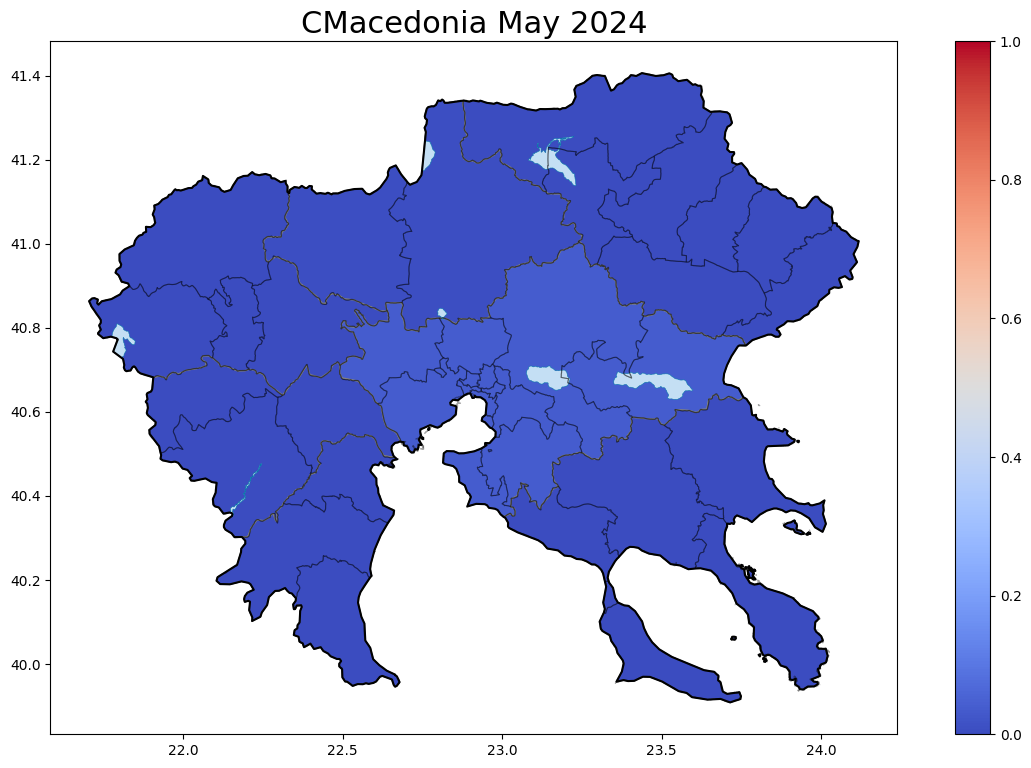

In [24]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)


plt.title(f'{NUTS2} {month_dict.get(results.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [25]:
color_0 = '#5686db'
color_50 = '#f98c37'
color_100 = '#e81015'

# Define the colorscale
colorscale_custom_1 = [
    [0, color_0],
    # [0.25, color_25],
    [0.5, color_50],
    # [0.75, color_75],
    [1, color_100]
]

In [26]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, greece_nuts2_gdf, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=colorscale_custom_1, opacity=0.75, fig_title = 'Central Macedonia May 2024',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

fig.show()

In [27]:
color_0 = '#3a4cc0'

color_50 = '#f87e31'

color_100 = '#b40526'

# Define the colorscale
colorscale_custom_2 = [
    [0, color_0],
 
    [0.5, color_50],
 
    [1, color_100]
]

In [28]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, greece_nuts2_gdf, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=colorscale_custom_2, opacity=0.75, fig_title = 'Central Macedonia May 2024',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

fig.show()

In [29]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, #greece_lau1, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, fig_title = 'Central Macedonia May 2024',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

fig.show()

In [30]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL521,2024,5,22.2180,40.5521,0.002387,Ημαθία,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
1,EL522,2024,5,23.1390,40.6936,0.035358,Θεσσαλονίκη,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
2,EL523,2024,5,22.7623,41.0163,0.006745,Κιλκίς,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
3,EL524,2024,5,22.1098,40.8888,0.003850,Πέλλα,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
4,EL525,2024,5,22.4424,40.2700,0.000936,Πιερία,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."
5,EL526,2024,5,23.5440,41.0843,0.002697,Σέρρες,"POLYGON ((23.62422 41.37573, 23.62617 41.36319..."
6,EL527,2024,5,23.5315,40.3634,0.001869,Χαλκιδική,"MULTIPOLYGON (((23.75687 40.63456, 23.76634 40..."


In [31]:
results.to_file(f'../../../data/{NUTS2}/predictions/GR_{NUTS2}_NUTS3_Predictions_May_2024.shp', encoding = 'utf-8')

In [32]:
greece_lakes.to_file(f'../../../data/{NUTS2}/predictions/GR_{NUTS2}_Lakes.shp', encoding = 'utf-8')

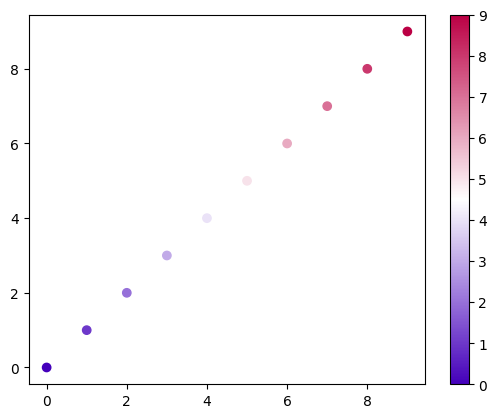

In [33]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define the color transitions
cdict = {'red':   ((0.0, 0.267004, 0.267004),
                   (0.5, 1.000000, 1.000000),
                   (1.0, 0.733333, 0.733333)),

         'green': ((0.0, 0.000000, 0.000000),
                   (0.5, 1.000000, 1.000000),
                   (1.0, 0.000000, 0.000000)),

         'blue':  ((0.0, 0.733333, 0.733333),
                   (0.5, 1.000000, 1.000000),
                   (1.0, 0.267004, 0.267004))
         }

# Create the colormap
custom_coolwarm = LinearSegmentedColormap('custom_coolwarm', cdict)

# Test it with a simple plot (replace with your data)
x = y = np.arange(10)
plt.scatter(x, y, c=y, cmap=custom_coolwarm)
plt.colorbar()
plt.show()

In [34]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, #greece_lau1, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(custom_coolwarm), opacity=0.75, fig_title = 'Central Macedonia May 2024',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

fig.show()

In [35]:
colors = plt.cm.get_cmap('coolwarm').colors


AttributeError: 'LinearSegmentedColormap' object has no attribute 'colors'

In [ ]:
cmap = plt.cm.get_cmap('coolwarm')
colors = cmap(np.arange(cmap.N))

In [ ]:
colors.shape

(256, 4)